In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import plotly.graph_objects as go
import plotly.express as px
import math

In [69]:
df = pd.read_csv('IoTPond3.csv')
df.head()

,created_at,entry_id,Temperature(C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Population,Fish_Length(cm),Fish_Weight(g)
0,2021-06-19 00:00:04 CET,1941,23.75,80,27.736,7.04911,5.15546,114,50,6.74,3.2
1,2021-06-19 00:00:26 CET,1942,23.75,80,4.195,7.09450,4.53072,114,50,6.74,3.2
2,2021-06-19 00:02:03 CET,1945,23.75,80,10.310,7.07635,5.21473,113,50,6.74,3.2
3,2021-06-19 00:02:26 CET,1946,23.75,81,1.196,7.07181,5.41747,100,50,6.74,3.2
4,2021-06-19 00:03:31 CET,1948,23.75,80,2.338,7.08996,5.45899,112,50,6.74,3.2


In [70]:
print(df.isnull().sum())

created_at                  0
entry_id                    0
Temperature(C)              0
Turbidity(NTU)              0
Dissolved Oxygen(g/ml)      0
PH                          0
Ammonia(g/ml)             107
Nitrate(g/ml)               0
Population                  0
Fish_Length(cm)             0
Fish_Weight(g)              0
dtype: int64


In [71]:
df['Ammonia(g/ml)'].fillna(df['Ammonia(g/ml)'].mean(), inplace=True)

In [72]:
print(df.isnull().sum())

created_at                0
entry_id                  0
Temperature(C)            0
Turbidity(NTU)            0
Dissolved Oxygen(g/ml)    0
PH                        0
Ammonia(g/ml)             0
Nitrate(g/ml)             0
Population                0
Fish_Length(cm)           0
Fish_Weight(g)            0
dtype: int64


In [73]:
df.describe()

,entry_id,Temperature(C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Population,Fish_Length(cm),Fish_Weight(g)
count,169185.000000,169185.000000,169185.000000,169185.000000,169185.000000,1.691850e+05,169185.000000,169185.0,169185.000000,169185.000000
mean,88079.861164,23.779466,83.384898,7.456181,7.184931,inf,380.670804,50.0,16.058793,44.259006
std,48888.942496,1.549207,26.651853,6.410530,0.629428,NaN,255.443631,0.0,5.001695,45.519340
min,1941.000000,-127.000000,8.000000,0.008000,-0.531800,0.000000e+00,0.000000,50.0,6.740000,3.200000
25%,45813.000000,23.375000,80.000000,5.080000,7.244310,5.781210e+00,123.000000,50.0,13.320000,19.380000
50%,88109.000000,23.750000,98.000000,5.080000,7.307860,2.942574e+01,417.000000,50.0,15.540000,35.830000
75%,130405.000000,24.125000,100.000000,8.088000,7.344170,1.046599e+03,585.000000,50.0,18.860000,46.680000
max,172701.000000,26.562500,100.000000,41.384000,11.456930,inf,3870.000000,50.0,33.000000,294.920000


In [74]:
df.shape

(169185, 11)

In [75]:
df['created_at'] = pd.to_datetime(df['created_at'], format='%Y-%m-%d %H:%M:%S %Z', utc=True)

In [76]:
df['created_at'] = pd.to_datetime(df.created_at)

#split columns
df["Date"] = df["created_at"].dt.day
df["month"] = df["created_at"].dt.month
df['year']=df['created_at'].dt.year
df['hour']=df['created_at'].dt.hour
df['minutes']=df['created_at'].dt.minute
df['seconds']=df['created_at'].dt.second

In [77]:
df.head()

,created_at,entry_id,Temperature(C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Population,Fish_Length(cm),Fish_Weight(g),Date,month,year,hour,minutes,seconds
0,2021-06-18 22:00:04+00:00,1941,23.75,80,27.736,7.04911,5.15546,114,50,6.74,3.2,18,6,2021,22,0,4
1,2021-06-18 22:00:26+00:00,1942,23.75,80,4.195,7.09450,4.53072,114,50,6.74,3.2,18,6,2021,22,0,26
2,2021-06-18 22:02:03+00:00,1945,23.75,80,10.310,7.07635,5.21473,113,50,6.74,3.2,18,6,2021,22,2,3
3,2021-06-18 22:02:26+00:00,1946,23.75,81,1.196,7.07181,5.41747,100,50,6.74,3.2,18,6,2021,22,2,26
4,2021-06-18 22:03:31+00:00,1948,23.75,80,2.338,7.08996,5.45899,112,50,6.74,3.2,18,6,2021,22,3,31


In [78]:
df.drop(["created_at"], axis = 1, inplace = True)

In [79]:
 df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Date'] = pd.to_numeric(df['Date'])

In [80]:
 df['month'] = pd.to_datetime(df['month'], errors='coerce')

df['month'] = pd.to_numeric(df['month'])

In [81]:
 df['year'] = pd.to_datetime(df['year'], errors='coerce')

df['year'] = pd.to_numeric(df['year'])

In [82]:
df['hour'] = pd.to_datetime(df['hour'], errors='coerce')

df['hour'] = pd.to_numeric(df['hour'])

In [83]:
df['minutes'] = pd.to_datetime(df['minutes'], errors='coerce')

df['minutes'] = pd.to_numeric(df['minutes'])

In [84]:
df['seconds'] = pd.to_datetime(df['seconds'], errors='coerce')

df['seconds'] = pd.to_numeric(df['seconds'])

In [85]:
df.fillna(df.mean(), inplace=True)
df.replace([np.inf, -np.inf], 1e9, inplace=True)

In [86]:
df.columns


Index(['entry_id', 'Temperature(C)', 'Turbidity(NTU)',
       'Dissolved Oxygen(g/ml)', 'PH', 'Ammonia(g/ml)', 'Nitrate(g/ml)',
       'Population', 'Fish_Length(cm)', 'Fish_Weight(g)', 'Date', 'month',
       'year', 'hour', 'minutes', 'seconds'],
      dtype='object')

In [87]:
df.rename(columns={'Temperature(C)': 'Temperature (C)'}, inplace=True)

In [88]:
df.head()

,entry_id,Temperature (C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Population,Fish_Length(cm),Fish_Weight(g),Date,month,year,hour,minutes,seconds
0,1941,23.75,80,27.736,7.04911,5.15546,114,50,6.74,3.2,18,6,2021,22,0,4
1,1942,23.75,80,4.195,7.09450,4.53072,114,50,6.74,3.2,18,6,2021,22,0,26
2,1945,23.75,80,10.310,7.07635,5.21473,113,50,6.74,3.2,18,6,2021,22,2,3
3,1946,23.75,81,1.196,7.07181,5.41747,100,50,6.74,3.2,18,6,2021,22,2,26
4,1948,23.75,80,2.338,7.08996,5.45899,112,50,6.74,3.2,18,6,2021,22,3,31


In [89]:
for i in range(len(df)):
    if df.loc[i, "Temperature (C)"] < 20 or df.loc[i, "Temperature (C)"] > 30:
        df.loc[i, "Temperature (C)"] = df.loc[i-1, "Temperature (C)"]

In [90]:
for i in range(1,len(df)):
    if df.loc[i, "PH"] < 6 or df.loc[i, "PH"] > 8.5:
        df.loc[i, "PH"] = df.loc[i-1,'PH']

In [91]:
df.at[0, 'Dissolved Oxygen(g/ml)'] = 5

In [92]:
for i in range(1,len(df)):
    if df.loc[i, "Dissolved Oxygen(g/ml)"] < 5 or df.loc[i, "Dissolved Oxygen(g/ml)"] > 20:
        df.loc[i, "Dissolved Oxygen(g/ml)"] = df.loc[i-1, "Dissolved Oxygen(g/ml)"]

In [93]:
df["Ammonia(g/ml)"] = np.log(df["Ammonia(g/ml)"]) / 10.0
df["Ammonia(g/ml)"] = df["Ammonia(g/ml)"].abs()


In [94]:
df["Nitrate(g/ml)"] = df["Nitrate(g/ml)"].apply(np.sqrt)

In [95]:
df.fillna(df.mean(), inplace=True)
df.replace([np.inf, -np.inf], 1e-9, inplace=True)

In [96]:
df.describe()

,entry_id,Temperature (C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Population,Fish_Length(cm),Fish_Weight(g),Date,month,year,hour,minutes,seconds
count,169185.000000,169185.000000,169185.000000,169185.000000,169185.000000,1.691850e+05,169185.000000,169185.0,169185.000000,169185.000000,169185.000000,169185.000000,169185.0,169185.000000,169185.000000,169185.000000
mean,88079.861164,23.792858,83.384898,7.584495,7.264498,6.103845e-01,18.275962,50.0,16.058793,44.259006,16.301634,7.254969,2021.0,11.603517,29.503425,29.476792
std,48888.942496,0.619852,26.651853,3.944548,0.194401,5.158530e-01,6.830833,0.0,5.001695,45.519340,8.974913,0.744250,0.0,6.967993,17.317610,17.321835
min,1941.000000,22.312500,8.000000,5.000000,6.082200,1.000000e-09,0.000000,50.0,6.740000,3.200000,1.000000,6.000000,2021.0,0.000000,0.000000,0.000000
25%,45813.000000,23.375000,80.000000,5.080000,7.244310,2.637499e-01,11.090537,50.0,13.320000,19.380000,9.000000,7.000000,2021.0,5.000000,15.000000,14.000000
50%,88109.000000,23.750000,98.000000,5.080000,7.307860,4.049965e-01,20.420578,50.0,15.540000,35.830000,16.000000,7.000000,2021.0,12.000000,29.000000,29.000000
75%,130405.000000,24.125000,100.000000,8.962000,7.344170,8.468452e-01,24.186773,50.0,18.860000,46.680000,24.000000,8.000000,2021.0,18.000000,45.000000,44.000000
max,172701.000000,26.562500,100.000000,19.998000,8.497200,2.678005e+00,62.209324,50.0,33.000000,294.920000,31.000000,10.000000,2021.0,23.000000,59.000000,59.000000


In [97]:
df.drop(columns=['entry_id','Population'],axis=1,inplace=True)

In [98]:
columns=df.columns.tolist()
columns=columns[-6:]+columns[0:-6]
df=df[columns]

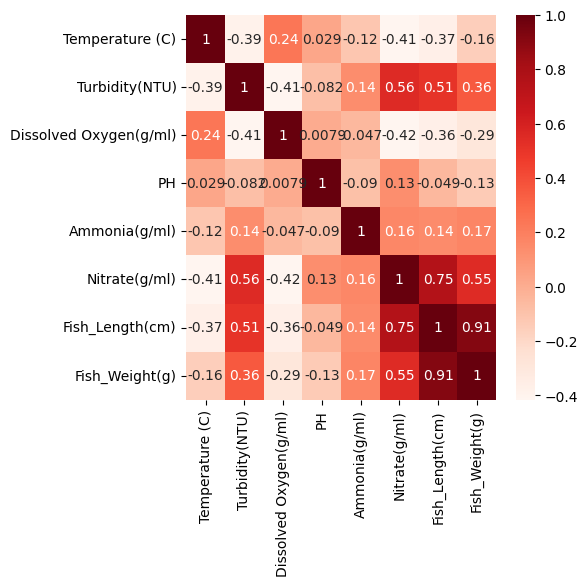

In [99]:
#creating a heatmap to show the correlation between the features
plt.figure(figsize=(5, 5))
x=df.iloc[:,6:]
cor = x.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

In [100]:
df.describe()

,Date,month,year,hour,minutes,seconds,Temperature (C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Fish_Length(cm),Fish_Weight(g)
count,169185.000000,169185.000000,169185.0,169185.000000,169185.000000,169185.000000,169185.000000,169185.000000,169185.000000,169185.000000,1.691850e+05,169185.000000,169185.000000,169185.000000
mean,16.301634,7.254969,2021.0,11.603517,29.503425,29.476792,23.792858,83.384898,7.584495,7.264498,6.103845e-01,18.275962,16.058793,44.259006
std,8.974913,0.744250,0.0,6.967993,17.317610,17.321835,0.619852,26.651853,3.944548,0.194401,5.158530e-01,6.830833,5.001695,45.519340
min,1.000000,6.000000,2021.0,0.000000,0.000000,0.000000,22.312500,8.000000,5.000000,6.082200,1.000000e-09,0.000000,6.740000,3.200000
25%,9.000000,7.000000,2021.0,5.000000,15.000000,14.000000,23.375000,80.000000,5.080000,7.244310,2.637499e-01,11.090537,13.320000,19.380000
50%,16.000000,7.000000,2021.0,12.000000,29.000000,29.000000,23.750000,98.000000,5.080000,7.307860,4.049965e-01,20.420578,15.540000,35.830000
75%,24.000000,8.000000,2021.0,18.000000,45.000000,44.000000,24.125000,100.000000,8.962000,7.344170,8.468452e-01,24.186773,18.860000,46.680000
max,31.000000,10.000000,2021.0,23.000000,59.000000,59.000000,26.562500,100.000000,19.998000,8.497200,2.678005e+00,62.209324,33.000000,294.920000
